In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/genulens/genprior/gentool/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="/moao38_7/nunota/genulens/genprior/test_data/riron_ns.dat",
                      mass_path="/moao38_7/nunota/binfit/work/MB23162/tool/check_Mhist.dat",
                      mu_path="/moao38_7/nunota/genulens/genprior/test_data/murel_hist.dat")
gapmoe_model.set_data(fREM_range=[0])

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_lom_simu_01_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples_wo_lom = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs_wo_lom = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS_wo_lom = np.concatenate(all_flat_blobs, axis=0)

non_flat_chain_wo_lom_lom = sampler.get_chain(flat=False, discard=burnin, thin=thin)
non_flat_lnprobs_wo_lom =  sampler.get_log_prob(flat=False, discard=burnin, thin=thin)
thE_wo_lom =  joint_flat_thS_wo_lom / joint_flat_samples_wo_lom[:,6]

In [4]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_para_simu_01_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples_wo_para = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs_wo_para = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS_wo_para = np.concatenate(all_flat_blobs, axis=0)

non_flat_chain_wo_lom_para = sampler.get_chain(flat=False, discard=burnin, thin=thin)
non_flat_lnprobs_wo_para =  sampler.get_log_prob(flat=False, discard=burnin, thin=thin)
thE_wo_para =  joint_flat_thS_wo_para / joint_flat_samples_wo_para[:,6]

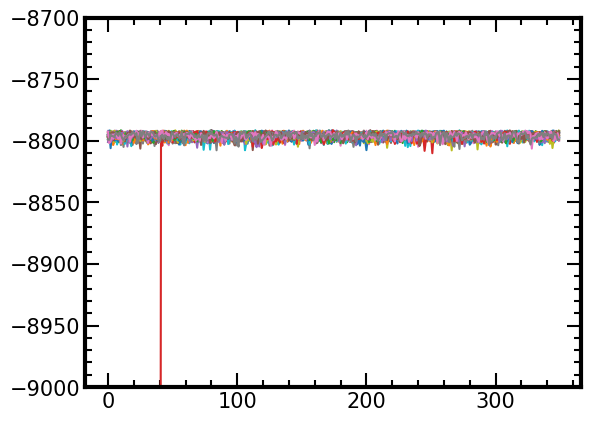

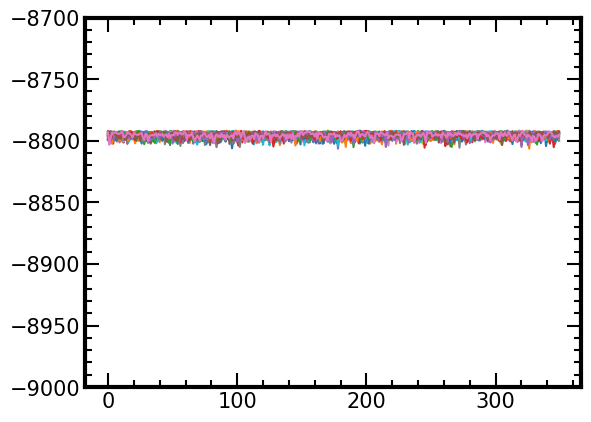

In [5]:
for i in range(non_flat_lnprobs_wo_lom.shape[1]):
    plt.plot(non_flat_lnprobs_wo_lom[:,i])
    
plt.minorticks_on()
plt.ylim(-9000,-8700)
plt.show()

for i in range(non_flat_lnprobs_wo_para.shape[1]):
    plt.plot(non_flat_lnprobs_wo_para[:,i])
    
plt.minorticks_on()
plt.ylim(-9000,-8700)
plt.show()

In [6]:
ind = np.where(joint_flat_lnprobs_wo_lom> -9000)
joint_flat_samples_wo_lom = joint_flat_samples_wo_lom[ind]
joint_flat_lnprobs_wo_lom = joint_flat_lnprobs_wo_lom[ind]
joint_flat_thS_wo_lom = joint_flat_thS_wo_lom[ind]

ind = np.where(joint_flat_lnprobs_wo_para> -9000)
joint_flat_samples_wo_para = joint_flat_samples_wo_para[ind]
joint_flat_lnprobs_wo_para = joint_flat_lnprobs_wo_para[ind]
joint_flat_thS_wo_para = joint_flat_thS_wo_para[ind]

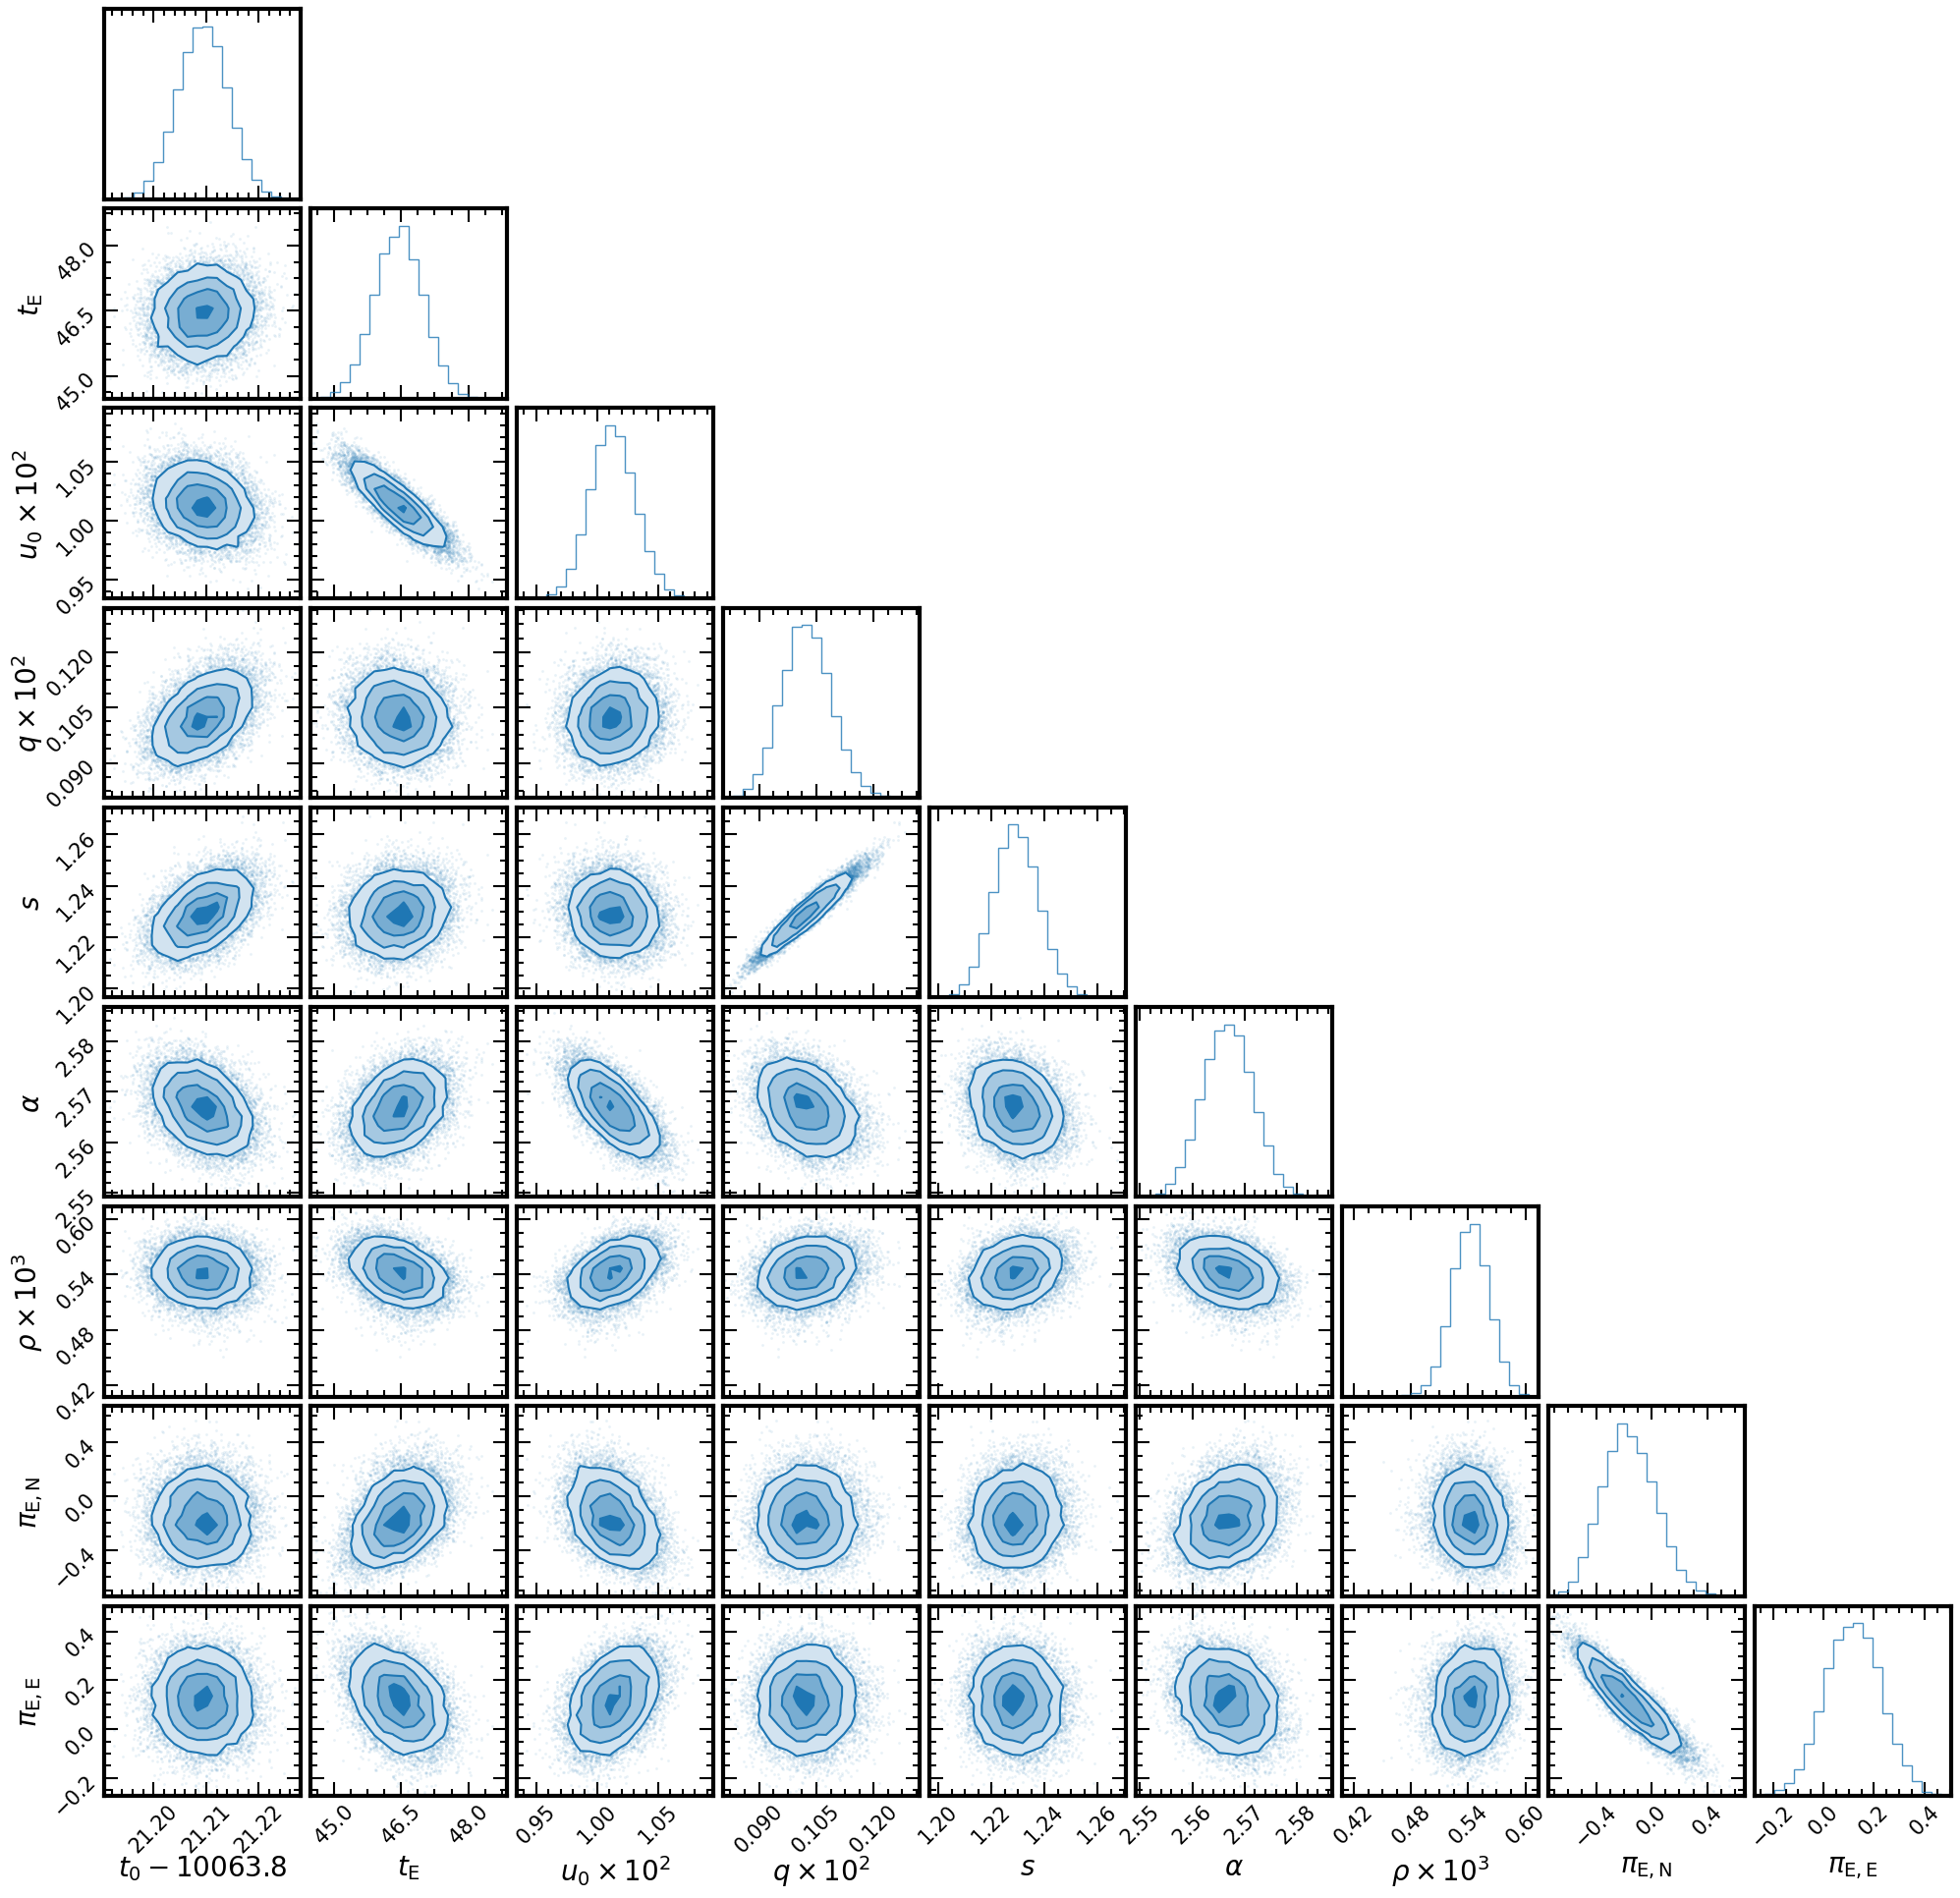

In [7]:
combined_array = np.hstack([
    joint_flat_samples_wo_lom,
])
Msun_in_Mearth = 332946.0487
Mjup_in_Mearth = 317.83
# --- スケーリング ---
scaled_array = combined_array.copy()
scaled_array[:, 0] -= 10063.8   # t0 shift
scaled_array[:, 2] *= 1e2       # u0 × 10²
scaled_array[:, 3] *= 1e2       # q × 10²
scaled_array[:, 6] *= 1e3       # rho × 10³
scaled_array[:, 9:12] *= 1e3    # gamma1-3 × 10³

labels = [
    r"$t_0 - 10063.8$",   # 0
    r"$t_{\rm E}$",             # 1
    r"$u_0 \times 10^2$", # 2
    r"$q \times 10^2$",   # 3
    r"$s$",               # 4
    r"$\alpha$",          # 5
    r"$\rho \times 10^3$",# 6
    r"$\pi_{\rm E,N}$",       # 7
    r"$\pi_{\rm E,E}$",       # 8
    r"$\gamma_1 \times 10^3$",  # 9
    r"$\gamma_2 \times 10^3$",  # 10
    r"$\gamma_3 \times 10^3$",  # 11
]

# --- corner plot ---
fig = corner.corner(
    scaled_array,
    labels=labels,
    show_titles=False,
    title_fmt=".2f",
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 20},
    max_n_ticks=4,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    color="C0",
    hist_kwargs={"density": True, "alpha": 0.8},
)
for ax in fig.get_axes():
    ax.minorticks_on()

plt.subplots_adjust(top=0.95)
plt.show()

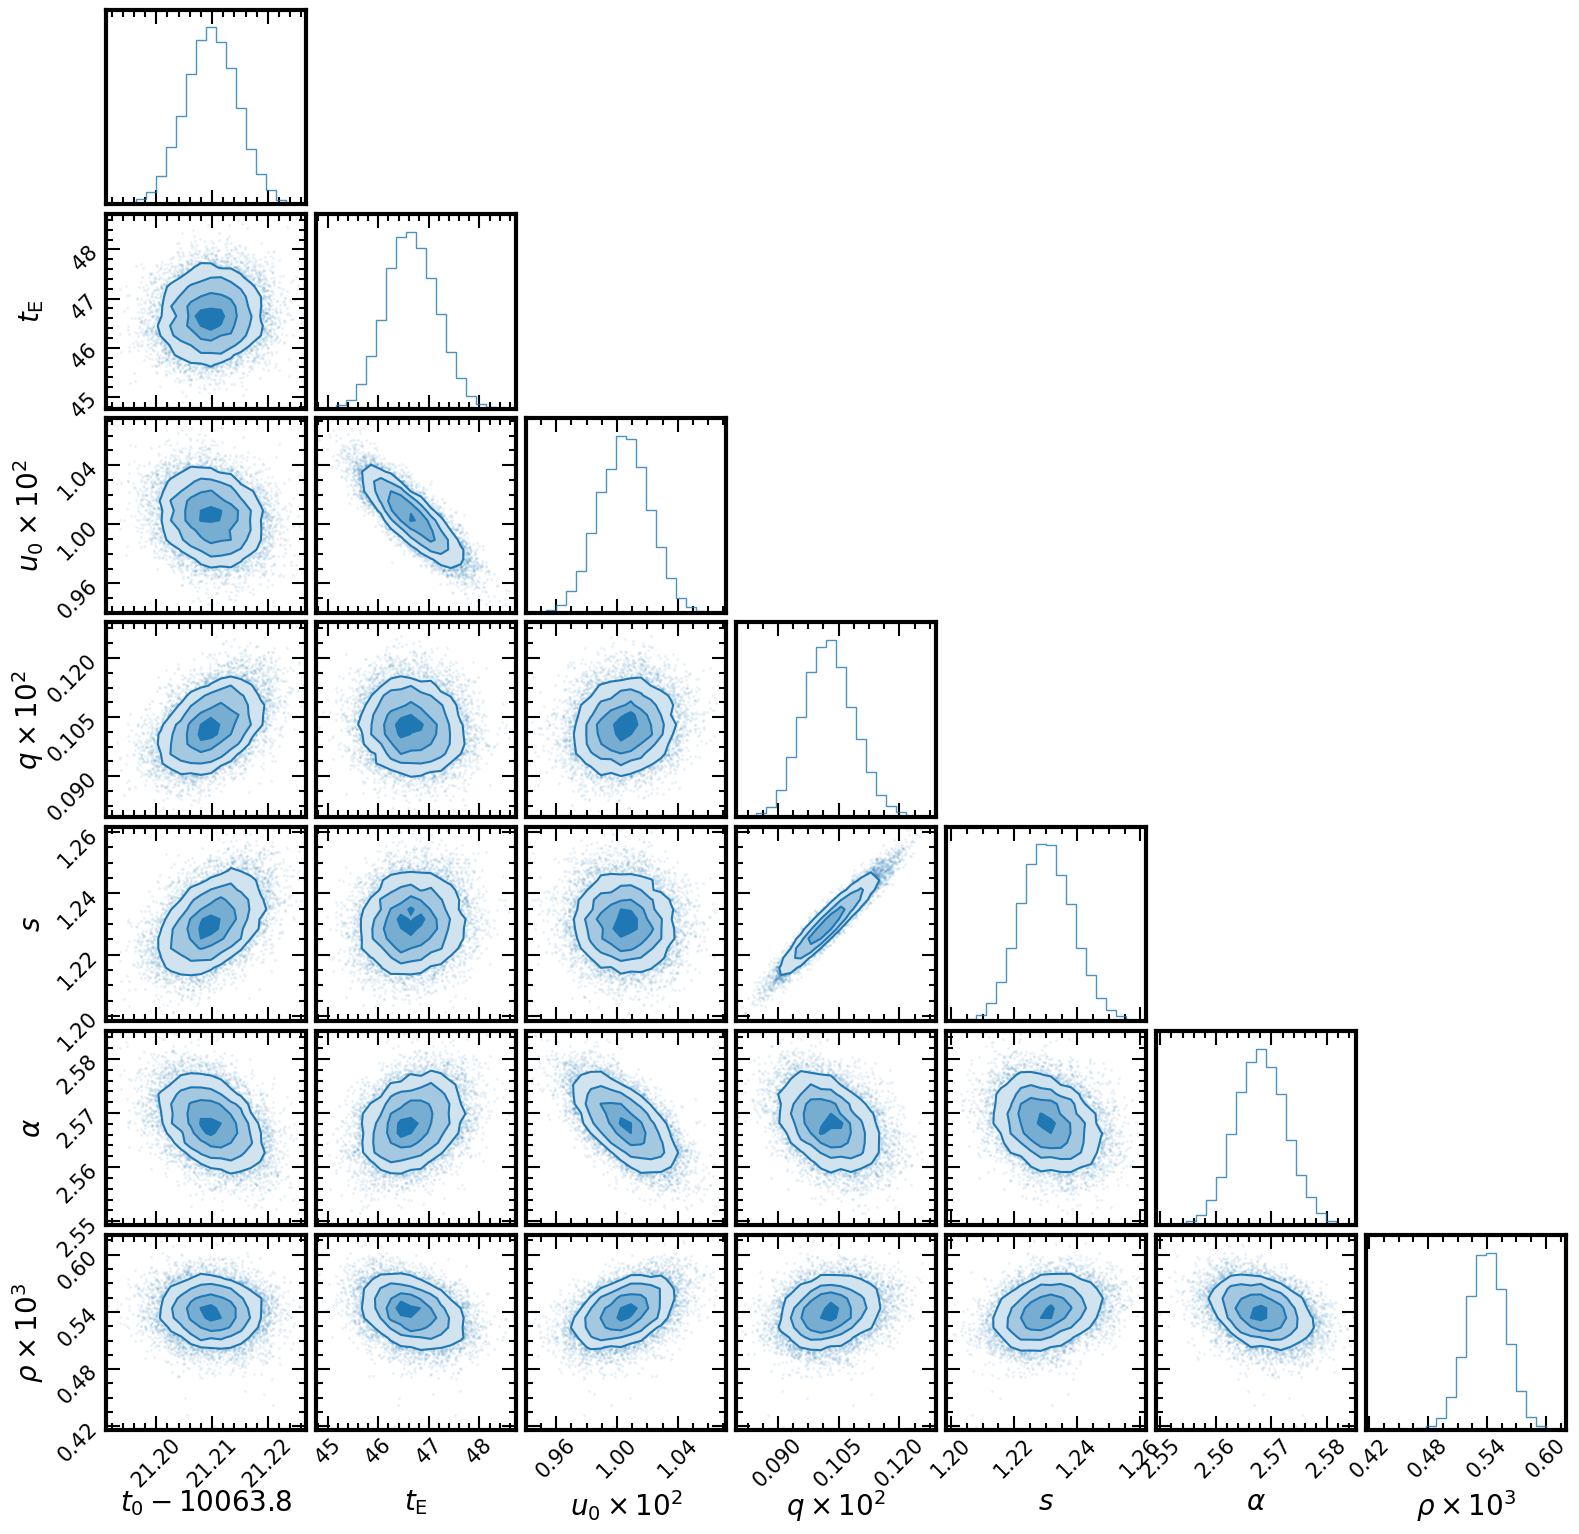

In [8]:
combined_array = np.hstack([
    joint_flat_samples_wo_para,
])
Msun_in_Mearth = 332946.0487
Mjup_in_Mearth = 317.83
# --- スケーリング ---
scaled_array = combined_array.copy()
scaled_array[:, 0] -= 10063.8   # t0 shift
scaled_array[:, 2] *= 1e2       # u0 × 10²
scaled_array[:, 3] *= 1e2       # q × 10²
scaled_array[:, 6] *= 1e3       # rho × 10³

labels = [
    r"$t_0 - 10063.8$",   # 0
    r"$t_{\rm E}$",             # 1
    r"$u_0 \times 10^2$", # 2
    r"$q \times 10^2$",   # 3
    r"$s$",               # 4
    r"$\alpha$",          # 5
    r"$\rho \times 10^3$",# 6
    r"$\pi_{\rm E,N}$",       # 7
    r"$\pi_{\rm E,E}$",       # 8
]

# --- corner plot ---
fig = corner.corner(
    scaled_array,
    labels=labels,
    show_titles=False,
    title_fmt=".2f",
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 20},
    max_n_ticks=4,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    color="C0",
    hist_kwargs={"density": True, "alpha": 0.8},
)
for ax in fig.get_axes():
    ax.minorticks_on()

plt.subplots_adjust(top=0.95)
plt.show()

In [13]:
def print_range_para(samples, thE_samples):
    piE_sample = np.sqrt(samples[:, 7]**2 + samples[:, 8]**2)

    tE_ll, tE_med, tE_ul = np.percentile(samples[:, 1], [16, 50, 84])    
    thE_ll, thE_med, thE_ul = np.percentile(thE_samples, [16, 50, 84])
    piEN_ll, piEN_med, piEN_ul = np.percentile(samples[:, 7], [16, 50, 84])
    piEE_ll, piEE_med, piEE_ul = np.percentile(samples[:, 8], [16, 50, 84])

    tE_err = (tE_ul - tE_ll) / 2
    thE_err = (thE_ul - thE_ll) / 2
    piEN_err = (piEN_ul - piEN_ll) / 2
    piEE_err = (piEE_ul - piEE_ll) / 2

    print(f"./genulens tE {tE_med:.2f} {tE_err:.2f}  thetaE {thE_med:.2e} {thE_err:.2e}  piEN {piEN_med:.2f} {piEN_err:.2f}  piEE {piEE_med:.2f} {piEE_err:.2f} VERBOSITY 3 NlikeMIN 1e+6")
    
def print_range(samples, thE_samples):

    tE_ll, tE_med, tE_ul = np.percentile(samples[:, 1], [16, 50, 84])    
    thE_ll, thE_med, thE_ul = np.percentile(thE_samples, [16, 50, 84])

    tE_err = (tE_ul - tE_ll) / 2
    thE_err = (thE_ul - thE_ll) / 2

    print(f"./genulens tE {tE_med:.2f} {tE_err:.2f}  thetaE {thE_med:.2e} {thE_err:.2e} VERBOSITY 3 NlikeMIN 1e+6")

In [14]:
print_range_para(joint_flat_samples_wo_lom,thE_wo_lom)
print_range(joint_flat_samples_wo_para,thE_wo_para)

./genulens tE 46.45 0.54  thetaE 3.08e-01 3.08e-02  piEN -0.17 0.19  piEE 0.12 0.11 VERBOSITY 3 NlikeMIN 1e+6
./genulens tE 46.64 0.50  thetaE 3.14e-01 1.18e-01 VERBOSITY 3 NlikeMIN 1e+6


In [11]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_wo_lom = "../test_gal_result/genout_wo_lom_simu_01.dat"
data_wo_lom = np.genfromtxt(path_wo_lom, names=column_names)

path_wo_para = "../test_gal_result/genout_wo_para_simu_01.dat"
data_wo_para = np.genfromtxt(path_wo_para, names=column_names)

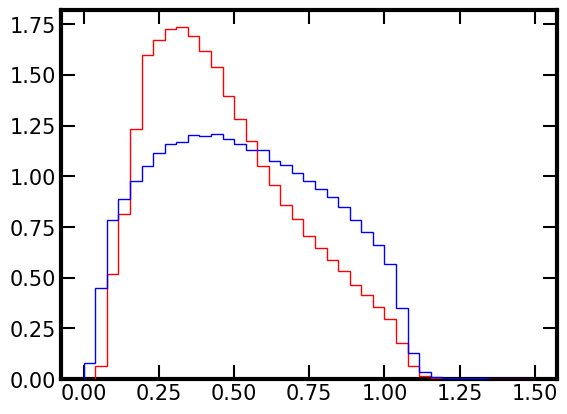

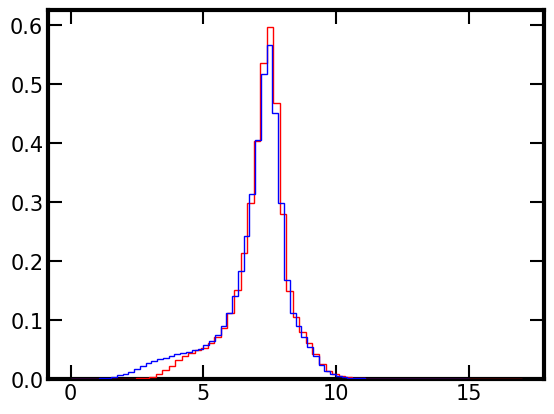

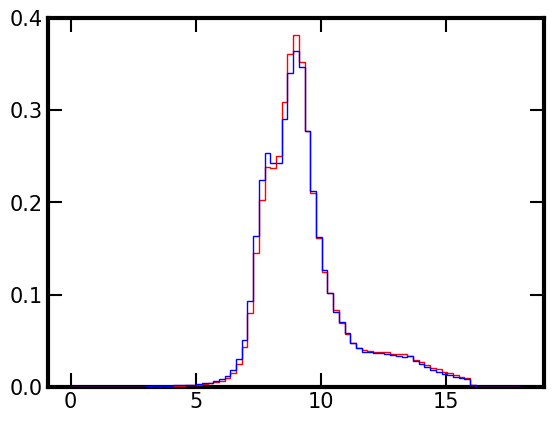

In [12]:
plt.hist(data_wo_lom["M_L"], bins=np.linspace(0, 1.5, 40),
         density=True,
         weights=data_wo_lom["wtj"],
         histtype="step", color="red", lw=5, label="Full Bayesian", zorder=10)

plt.hist(data_wo_para["M_L"], bins=np.linspace(0, 1.5, 40),
         density=True,
         weights=data_wo_para["wtj"],
         histtype="step", color="blue", lw=5, label="Full Bayesian", zorder=10)
plt.show()

plt.hist(data_wo_lom["D_L"]*1e-3, bins=np.linspace(0, 17, 70),
         density=True,
         weights=data_wo_lom["wtj"],
         histtype="step", color="red", lw=5, label="Full Bayesian", zorder=10)
plt.hist(data_wo_para["D_L"]*1e-3, bins=np.linspace(0, 15, 70),
         density=True,
         weights=data_wo_para["wtj"],
         histtype="step", color="blue", lw=5, label="Full Bayesian", zorder=10)
plt.show()

plt.hist(data_wo_lom["D_S"]*1e-3, bins=np.linspace(0, 18, 80),
         density=True,
         weights=data_wo_lom["wtj"],
         histtype="step", color="red", lw=5, label="Full Bayesian", zorder=10)
plt.hist(data_wo_para["D_S"]*1e-3, bins=np.linspace(0, 18, 80),
         density=True,
         weights=data_wo_para["wtj"],
         histtype="step", color="blue", lw=5, label="Full Bayesian", zorder=10)
plt.show()